# Install & Import Library

In [1]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 8.9 MB/s eta 0:00:00


In [2]:
# Install & Import Library
import os
import optuna
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, math, warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [3]:
# Tampilan dataframe yang lebih rapi
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Tree Cover Loss

In [4]:
# Load Dataset dari Google Drive / Colab Files
file_path = "/content/IDN.xlsx"

# Baca sheet Subnational 1 tree cover loss
df = pd.read_excel(file_path, sheet_name="Subnational 1 tree cover loss")

print("Dataset loaded with shape:", df.shape)
df.head()

Dataset loaded with shape: (272, 31)


,country,subnational1,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2012_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,tc_loss_ha_2005,tc_loss_ha_2006,tc_loss_ha_2007,tc_loss_ha_2008,tc_loss_ha_2009,tc_loss_ha_2010,tc_loss_ha_2011,tc_loss_ha_2012,tc_loss_ha_2013,tc_loss_ha_2014,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024
0,Indonesia,Aceh,0,5683650,5683650,5683650,129164,18402,11039,11858,19315,26677,21392,24304,36867,69393,40897,47777,50225,44602,63050,35718,54064,49775,50240,31054,33716,34795,32777,43810,52495
1,Indonesia,Aceh,10,5683650,5090906,4996298,129164,18325,10988,11830,19213,26563,21326,24221,36785,69241,40821,47582,49582,41930,59577,34386,50990,46781,47054,29148,31009,32516,30495,40110,47497
2,Indonesia,Aceh,15,5683650,5050168,4946855,129164,18309,10974,11827,19187,26537,21311,24202,36770,69196,40802,47550,49526,41776,59276,34261,50711,46489,46775,28962,30750,32292,30263,39754,47042
3,Indonesia,Aceh,20,5683650,5029128,4932162,129164,18297,10966,11822,19168,26510,21299,24188,36753,69166,40787,47527,49478,41639,59025,34159,50498,46263,46546,28829,30574,32117,30095,39486,46720
4,Indonesia,Aceh,25,5683650,5014670,4908701,129164,18289,10961,11818,19156,26495,21295,24181,36746,69148,40779,47513,49451,41567,58898,34109,50373,46141,46416,28758,30474,32020,30014,39341,46528


In [5]:
# Filter threshold 30% (standar Global Forest Watch)
df = df[df["threshold"] == 30].reset_index(drop=True)
print("Filtered rows (threshold=30%):", len(df))

Filtered rows (threshold=30%): 34


In [6]:
# Ubah format wide → long (yearly time series)
# Kolom yang memuat data loss per tahun (2001–2024)
loss_cols = [col for col in df.columns if "tc_loss_ha_" in col]

# Ubah menjadi long format
df_long = df.melt(
    id_vars=["country", "subnational1", "threshold", "extent_2000_ha"],
    value_vars=loss_cols,
    var_name="year",
    value_name="loss_ha"
)

# Ambil angka tahun dari nama kolom
df_long["year"] = df_long["year"].str.extract(r"(\d{4})").astype(int)

# Urutkan
df_long = df_long.sort_values(["subnational1", "year"]).reset_index(drop=True)

print("Long-format dataset ready:", df_long.shape)
df_long.head()

Long-format dataset ready: (816, 6)


,country,subnational1,threshold,extent_2000_ha,year,loss_ha
0,Indonesia,Aceh,30,4984708,2001,18278
1,Indonesia,Aceh,30,4984708,2002,10952
2,Indonesia,Aceh,30,4984708,2003,11816
3,Indonesia,Aceh,30,4984708,2004,19138
4,Indonesia,Aceh,30,4984708,2005,26479


In [7]:
# Hitung Laju Deforestasi Tahunan (% dari luas awal)
# Gunakan extent_2000_ha sebagai baseline luas hutan
df_long["loss_rate_%"] = (df_long["loss_ha"] / df_long["extent_2000_ha"]) * 100

# Cek total per tahun (nasional)
national_trend = (
    df_long.groupby("year")["loss_ha"].sum().reset_index()
)
national_trend["loss_rate_%"] = national_trend["loss_ha"] / df_long["extent_2000_ha"].sum() * 100

national_trend.head()

,year,loss_ha,loss_rate_%
0,2001,744082,0.02
1,2002,855266,0.02
2,2003,544809,0.01
3,2004,1289035,0.03
4,2005,1182433,0.03


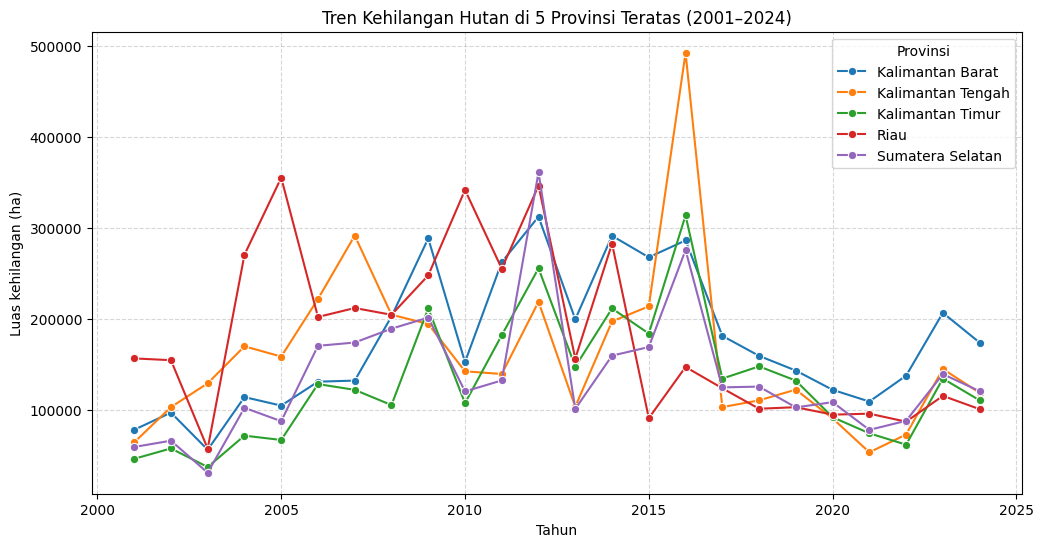

In [8]:
# Visualisasi Contoh Per Provinsi
# Pilih 5 provinsi dengan rata-rata loss terbesar
top5 = (
    df_long.groupby("subnational1")["loss_ha"].mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_long[df_long["subnational1"].isin(top5)],
    x="year",
    y="loss_ha",
    hue="subnational1",
    marker="o"
)
plt.title("Tren Kehilangan Hutan di 5 Provinsi Teratas (2001–2024)")
plt.ylabel("Luas kehilangan (ha)")
plt.xlabel("Tahun")
plt.legend(title="Provinsi")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Carbon Data


In [9]:
# Baca sheet Subnational 1 tree cover loss
df_carbon = pd.read_excel(file_path, sheet_name="Subnational 1 carbon data")

print("Dataset loaded with shape:", df.shape)
df_carbon = df_carbon[df_carbon["umd_tree_cover_density_2000__threshold"] == 30]
df_carbon.head()

Dataset loaded with shape: (34, 31)


,country,subnational1,umd_tree_cover_density_2000__threshold,umd_tree_cover_extent_2000__ha,gfw_aboveground_carbon_stocks_2000__Mg_C,avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1,gfw_forest_carbon_gross_emissions__Mg_CO2e_yr-1,gfw_forest_carbon_gross_removals__Mg_CO2_yr-1,gfw_forest_carbon_net_flux__Mg_CO2e_yr-1,gfw_forest_carbon_gross_emissions_2001__Mg_CO2e,gfw_forest_carbon_gross_emissions_2002__Mg_CO2e,gfw_forest_carbon_gross_emissions_2003__Mg_CO2e,gfw_forest_carbon_gross_emissions_2004__Mg_CO2e,gfw_forest_carbon_gross_emissions_2005__Mg_CO2e,gfw_forest_carbon_gross_emissions_2006__Mg_CO2e,gfw_forest_carbon_gross_emissions_2007__Mg_CO2e,gfw_forest_carbon_gross_emissions_2008__Mg_CO2e,gfw_forest_carbon_gross_emissions_2009__Mg_CO2e,gfw_forest_carbon_gross_emissions_2010__Mg_CO2e,gfw_forest_carbon_gross_emissions_2011__Mg_CO2e,gfw_forest_carbon_gross_emissions_2012__Mg_CO2e,gfw_forest_carbon_gross_emissions_2013__Mg_CO2e,gfw_forest_carbon_gross_emissions_2014__Mg_CO2e,gfw_forest_carbon_gross_emissions_2015__Mg_CO2e,gfw_forest_carbon_gross_emissions_2016__Mg_CO2e,gfw_forest_carbon_gross_emissions_2017__Mg_CO2e,gfw_forest_carbon_gross_emissions_2018__Mg_CO2e,gfw_forest_carbon_gross_emissions_2019__Mg_CO2e,gfw_forest_carbon_gross_emissions_2020__Mg_CO2e,gfw_forest_carbon_gross_emissions_2021__Mg_CO2e,gfw_forest_carbon_gross_emissions_2022__Mg_CO2e,gfw_forest_carbon_gross_emissions_2023__Mg_CO2e,gfw_forest_carbon_gross_emissions_2024__Mg_CO2e
5,Indonesia,Aceh,30,4984708,653101544,544,22138237,13571223,8567015,10781164,6627106,8026562,11548791,17345183,13845766,15217238,24828757,44802236,25634918,31277948,31813634,24213932,36641364,20419815,29597570,26984846,27851704,17771125,18601460,18974147,16989501,23348363,28174569
13,Indonesia,Bali,30,365485,39151857,491,215607,2388648,-2173040,260325,190618,117400,219024,148261,321987,315182,146969,232894,125464,133383,452548,204263,508923,76643,96433,155514,161045,429538,109182,124862,168103,365681,110329
21,Indonesia,Bangka Belitung,30,1332845,106312312,283,15221676,7397481,7824198,7005063,5562797,3487235,11477498,10079529,10751927,12008264,11226378,33402713,12361376,16964282,21360184,9630177,22150159,22577478,36821355,12950327,10287578,10721349,12029032,15885973,16706101,24505926,15367547
29,Indonesia,Banten,30,561723,56287349,513,1321451,3632176,-2310725,618476,1042788,164982,827685,311460,1089522,605411,562003,1701980,983311,1374312,2150205,1100213,1390639,1638703,1155343,2099270,2117123,2857726,1271610,1181129,929614,2388259,2153062
37,Indonesia,Bengkulu,30,1795200,231746921,499,13933685,7408354,6525332,10135589,7523117,5800440,18343674,9223426,15951261,12489087,15627311,13382843,11253547,18100728,20702595,9464223,13959398,14343184,16964333,18982493,17413860,12357843,11420715,9891659,16676254,19303155,15097704


In [10]:
# Memilih Kolom Carbon (stok karbon & emisi tahunan)
carbon_cols = [
    "country", "subnational1", "umd_tree_cover_density_2000__threshold",
    "gfw_aboveground_carbon_stocks_2000__Mg_C",
    "avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1"
]

In [11]:
# Kolom emisi tahunan (filter only columns ending with a year)
emission_cols = [c for c in df_carbon.columns if "gross_emissions_" in c]
carbon_long = df_carbon.melt(
    id_vars=carbon_cols,
    value_vars=emission_cols,
    var_name="year",
    value_name="emission_Mg_CO2e"
)

In [12]:
# Ambil angka tahun dari nama kolom
carbon_long["year"] = carbon_long["year"].str.extract(r"(\d{4})")

# Hapus baris tanpa angka tahun (NaN)
carbon_long = carbon_long.dropna(subset=["year"]).reset_index(drop=True)

# Konversi ke integer
carbon_long["year"] = carbon_long["year"].astype(int)
carbon_long["year"].unique()[:10]

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010])

# Merge dengan tree cover loss

In [13]:
# Gabungkan dengan tree cover loss
merged = pd.merge(
    df_long,
    carbon_long,
    left_on=["subnational1", "year"],
    right_on=["subnational1", "year"],
    how="left"
)

print("Dataset gabungan deforestasi + karbon:", merged.shape)
merged.head()

Dataset gabungan deforestasi + karbon: (816, 12)


,country_x,subnational1,threshold,extent_2000_ha,year,loss_ha,loss_rate_%,country_y,umd_tree_cover_density_2000__threshold,gfw_aboveground_carbon_stocks_2000__Mg_C,avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1,emission_Mg_CO2e
0,Indonesia,Aceh,30,4984708,2001,18278,0.37,Indonesia,30,653101544,544,10781164
1,Indonesia,Aceh,30,4984708,2002,10952,0.22,Indonesia,30,653101544,544,6627106
2,Indonesia,Aceh,30,4984708,2003,11816,0.24,Indonesia,30,653101544,544,8026562
3,Indonesia,Aceh,30,4984708,2004,19138,0.38,Indonesia,30,653101544,544,11548791
4,Indonesia,Aceh,30,4984708,2005,26479,0.53,Indonesia,30,653101544,544,17345183


# Visualisasi Tren

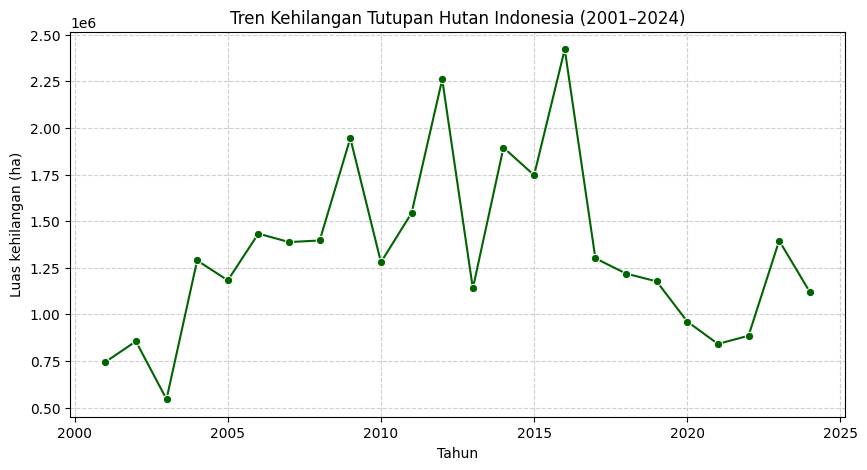

In [14]:
# Visualisasi Tren Tree Cover Loss Nasional
plt.figure(figsize=(10, 5))
sns.lineplot(data=national_trend, x="year", y="loss_ha", marker="o", color="darkgreen")
plt.title("Tren Kehilangan Tutupan Hutan Indonesia (2001–2024)")
plt.ylabel("Luas kehilangan (ha)")
plt.xlabel("Tahun")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

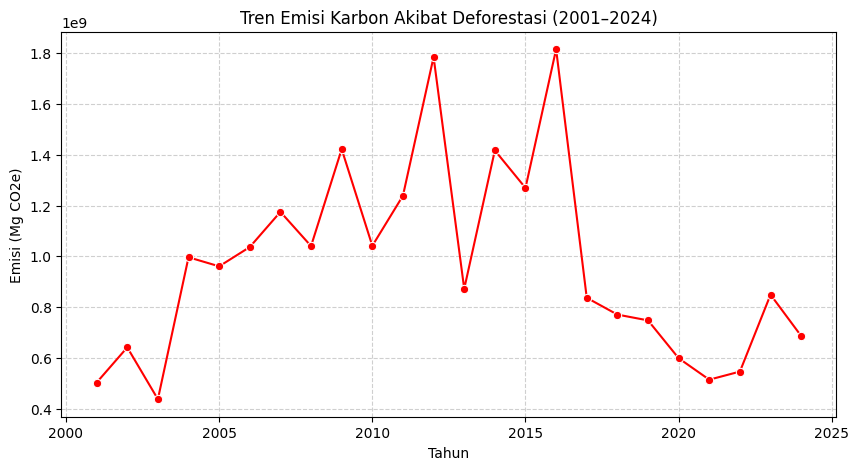

In [15]:
# Total emisi karbon per tahun di Indonesia
carbon_trend = merged.groupby("year")["emission_Mg_CO2e"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=carbon_trend, x="year", y="emission_Mg_CO2e", color="red", marker="o")
plt.title("Tren Emisi Karbon Akibat Deforestasi (2001–2024)")
plt.xlabel("Tahun")
plt.ylabel("Emisi (Mg CO2e)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Data Cleaning (After Merged)

In [16]:
cols_keep = [
    "subnational1", "year",
    "extent_2000_ha", "loss_ha", "loss_rate_%",
    "gfw_aboveground_carbon_stocks_2000__Mg_C",
    "avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1",
    "emission_Mg_CO2e"
]

df_clean = merged[cols_keep].copy()

In [17]:
# Menambahkan Kolom Estimasi Karbon Hilang (C → CO₂e)
df_clean["emission_estimated_CO2e"] = (
    df_clean["loss_ha"] *
    df_clean["avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1"] *
    3.67 # konversi C ke CO₂e
)

In [18]:
# Cek jumlah duplikat berdasarkan provinsi dan tahun
df_clean.duplicated(subset=["subnational1", "year"]).sum()

np.int64(0)

In [19]:
df_clean.head()

,subnational1,year,extent_2000_ha,loss_ha,loss_rate_%,gfw_aboveground_carbon_stocks_2000__Mg_C,avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1,emission_Mg_CO2e,emission_estimated_CO2e
0,Aceh,2001,4984708,18278,0.37,653101544,544,10781164,"36,491,661.44"
1,Aceh,2002,4984708,10952,0.22,653101544,544,6627106,"21,865,448.96"
2,Aceh,2003,4984708,11816,0.24,653101544,544,8026562,"23,590,407.68"
3,Aceh,2004,4984708,19138,0.38,653101544,544,11548791,"38,208,634.24"
4,Aceh,2005,4984708,26479,0.53,653101544,544,17345183,"52,864,793.92"


In [20]:
df_clean["carbon_loss_MgC"] = df_clean["loss_ha"] * df_clean["avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1"] # menghitung carbon loss

df_clean[["subnational1", "year", "loss_ha", "carbon_loss_MgC", "emission_estimated_CO2e"]].head()

,subnational1,year,loss_ha,carbon_loss_MgC,emission_estimated_CO2e
0,Aceh,2001,18278,9943232,"36,491,661.44"
1,Aceh,2002,10952,5957888,"21,865,448.96"
2,Aceh,2003,11816,6427904,"23,590,407.68"
3,Aceh,2004,19138,10411072,"38,208,634.24"
4,Aceh,2005,26479,14404576,"52,864,793.92"


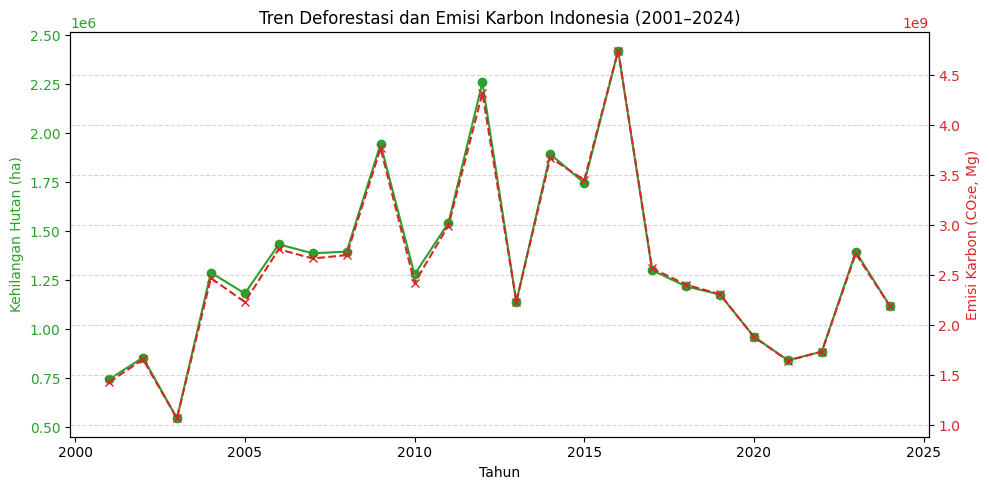

In [21]:
# Visualisasi Tren Emisi Carbon dengan Tree Cover Loss Nasional
national = (
    df_clean.groupby("year")[["loss_ha", "emission_estimated_CO2e"]]
    .sum().reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:green"
ax1.set_xlabel("Tahun")
ax1.set_ylabel("Kehilangan Hutan (ha)", color=color)
ax1.plot(national["year"], national["loss_ha"], color=color, marker="o", label="Deforestasi (ha)")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Emisi Karbon (CO₂e, Mg)", color=color)
ax2.plot(national["year"], national["emission_estimated_CO2e"], color=color, marker="x", linestyle="--", label="Emisi CO₂e")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Tren Deforestasi dan Emisi Karbon Indonesia (2001–2024)")
fig.tight_layout()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [22]:
output_path = "/content/deforestation_carbon_ready.csv"
df_clean.to_csv(output_path, index=False)
print("Dataset disimpan di:", output_path)

Dataset disimpan di: /content/deforestation_carbon_ready.csv


# Feature Engineering

In [23]:
df = df_clean.copy().sort_values(['subnational1', 'year']).reset_index(drop=True)

In [24]:
# Gunakan lag & rolling yang lebih panjang
lags = [1, 2, 3, 5, 7, 10]
rolling_windows = [3, 5, 7, 10]

for lag in lags:
    df[f'lag_{lag}'] = df.groupby('subnational1')['loss_ha'].shift(lag)

for w in rolling_windows:
    df[f'roll_mean_{w}'] = df.groupby('subnational1')['loss_ha'].shift(1).rolling(w).mean()
    df[f'roll_std_{w}']  = df.groupby('subnational1')['loss_ha'].shift(1).rolling(w).std()
    df[f'pct_change_{w}'] = df.groupby('subnational1')['loss_ha'].pct_change(periods=w)

# Fitur tren & musiman
df["trend"] = df.groupby("subnational1").cumcount()
df["sin_year"] = np.sin(2 * np.pi * df["year"] / 10)
df["cos_year"] = np.cos(2 * np.pi * df["year"] / 10)

# Bersihkan nilai tak valid
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [25]:
# Hilangkan baris awal yang belum punya lag lengkap
df = df.dropna(subset=['lag_10']).reset_index(drop=True)

# Encode nama provinsi (label encoding)
le = LabelEncoder()
df['prov_enc'] = le.fit_transform(df['subnational1'].astype(str))

# Tambahkan rata-rata deforestasi provinsi (target encoding sederhana)
prov_mean = df.groupby('subnational1')['loss_ha'].mean().to_dict()
df['prov_mean_loss'] = df['subnational1'].map(prov_mean)

# Pastikan semua kolom numerik aman
df = df.fillna(0)

# Fitur akhir
FEATURES = [
    'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_10',
    'roll_mean_3', 'roll_mean_5', 'roll_mean_7', 'roll_mean_10',
    'roll_std_3', 'roll_std_5', 'roll_std_7', 'roll_std_10',
    'pct_change_3', 'pct_change_5', 'pct_change_7', 'pct_change_10',
    'year', 'trend', 'sin_year', 'cos_year',
    'extent_2000_ha', 'avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1',
    'prov_enc', 'prov_mean_loss'
]
TARGET = 'loss_ha'

print("Total fitur digunakan:", len(FEATURES))

Total fitur digunakan: 26


In [26]:
# Konversi tipe data
df["year"] = df["year"].astype(int)
df["prov_enc"] = df["prov_enc"].astype(int)

In [27]:
feature_ready_path = "/content/deforestation_features_ready.csv"
df.to_csv(feature_ready_path, index=False)
print(f"Dataset feature-engineered disimpan di: {feature_ready_path}")

Dataset feature-engineered disimpan di: /content/deforestation_features_ready.csv


# Split Data

In [28]:
df_model = df.copy()

In [29]:
# Hilangkan nilai tak valid
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

In [30]:
# Target transformasi log
df_model["y_log"] = np.log1p(df_model[TARGET])

In [31]:
train_df = df[df['year'] <= 2020].copy()
val_df = df[(df['year'] >= 2021) & (df['year'] <= 2023)].copy()
test_df = df[df['year'] == 2024].copy()

print("Sizes: train", train_df.shape, "val", val_df.shape, "test", test_df.shape)

Sizes: train (680, 33) val (102, 33) test (34, 33)


In [32]:
train_df["y_log"] = np.log1p(train_df[TARGET])
val_df["y_log"] = np.log1p(val_df[TARGET])
test_df["y_log"] = np.log1p(test_df[TARGET])

In [33]:
X_train, y_train = train_df[FEATURES], train_df["y_log"]
X_val,   y_val   = val_df[FEATURES],   val_df["y_log"]
X_test,  y_test  = test_df[FEATURES],  test_df["y_log"]

groups = train_df["prov_enc"]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (680, 26), Val: (102, 26), Test: (34, 26)


In [34]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test, label=y_test)

# Optuna: Hyperparameter Tuning XGBoost

In [74]:
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "eval_metric": "rmse",
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08),
        "max_depth": trial.suggest_int("max_depth", 4, 9),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 6),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.3),
        "seed": 42,
    }

    evals = [(dtrain, "train"), (dval, "val")]
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        evals=evals,
        num_boost_round=1500,
        early_stopping_rounds=100,
        verbose_eval=False
    )

    # Prediksi
    y_pred_train = model.predict(dtrain)
    y_pred_val   = model.predict(dval)

    # RMSE (kembalikan dari log)
    rmse_train = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(y_pred_train)))
    rmse_val   = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred_val)))

    # Overfitting gap absolut (target → sekecil mungkin)
    gap = abs((rmse_val - rmse_train) / rmse_train) * 100

    return gap

In [75]:
study = optuna.create_study(direction="minimize", study_name="xgb_gap_tuning")
study.optimize(objective, n_trials=50, timeout=1800)

print("\nBest Trial:")
print("Best Params:", study.best_params)

[I 2025-10-29 01:30:53,561] A new study created in memory with name: xgb_gap_tuning
[I 2025-10-29 01:30:53,845] Trial 0 finished with value: 37.37671407351383 and parameters: {'learning_rate': 0.07101388874584068, 'max_depth': 5, 'min_child_weight': 2.3320731658701894, 'subsample': 0.616568150642464, 'colsample_bytree': 0.8245468881129328, 'reg_lambda': 0.1971178452334808, 'reg_alpha': 0.9586664160405288, 'gamma': 0.1311119886315922}. Best is trial 0 with value: 37.37671407351383.
[I 2025-10-29 01:30:54,148] Trial 1 finished with value: 42.69208025188839 and parameters: {'learning_rate': 0.06571920067102459, 'max_depth': 6, 'min_child_weight': 4.473794183157041, 'subsample': 0.6816140850349994, 'colsample_bytree': 0.9524503053800326, 'reg_lambda': 2.065021108683116, 'reg_alpha': 0.9061789504437661, 'gamma': 0.21618069454612895}. Best is trial 0 with value: 37.37671407351383.
[I 2025-10-29 01:30:54,522] Trial 2 finished with value: 48.5513804749615 and parameters: {'learning_rate': 0.03


Best Trial:
Best Params: {'learning_rate': 0.06565406755713839, 'max_depth': 5, 'min_child_weight': 3.05575383633739, 'subsample': 0.9748181203931159, 'colsample_bytree': 0.9172149686362163, 'reg_lambda': 2.9912987832995013, 'reg_alpha': 0.18823693232351638, 'gamma': 0.036196799988812714}


# Modelling (XGBoost)

In [76]:
best_params = study.best_params
best_params.update({
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42
})

In [77]:
evals = [(dtrain, "train"), (dval, "val")]
evals_result = {}

xgb_model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    evals=evals,
    num_boost_round=2000,
    early_stopping_rounds=150,
    verbose_eval=100,
    evals_result=evals_result
)

[0]	train-rmse:2.21428	val-rmse:2.14075
[100]	train-rmse:0.16419	val-rmse:0.22063
[200]	train-rmse:0.13643	val-rmse:0.21407
[300]	train-rmse:0.13535	val-rmse:0.21434
[354]	train-rmse:0.13470	val-rmse:0.21437


In [78]:
xgb_model.save_model("/content/xgb_optimized.json")

# Evaluasi & Overfitting Test

In [79]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

y_pred_train = xgb_model.predict(dtrain)
y_pred_val   = xgb_model.predict(dval)
y_pred_test  = xgb_model.predict(dtest)

train_rmse = rmse(y_train, y_pred_train)
val_rmse   = rmse(y_val, y_pred_val)
test_rmse  = rmse(y_test, y_pred_test)
r2_val     = r2_score(np.expm1(y_val), np.expm1(y_pred_val))

overfit_gap = ((val_rmse - train_rmse) / train_rmse) * 100

print("Evaluasi Model XGBoost (Optuna Tuned)")
print(f"Train RMSE : {train_rmse:,.2f}")
print(f"Val RMSE   : {val_rmse:,.2f}")
print(f"Test RMSE  : {test_rmse:,.2f}")
print(f"R² (val)   : {r2_val:.3f}")
print(f"Overfitting Gap : {overfit_gap:.2f}%")

Evaluasi Model XGBoost (Optuna Tuned)
Train RMSE : 9,191.39
Val RMSE   : 8,973.37
Test RMSE  : 4,803.71
R² (val)   : 0.947
Overfitting Gap : -2.37%


# Forecast

In [80]:
data_path = "/content/deforestation_features_ready.csv"
model_path = "/content/xgb_optimized.json"

df = pd.read_csv(data_path)
model = xgb.Booster()
model.load_model(model_path)

In [81]:
latest_year = int(df['year'].max())
forecast_horizon = 6

In [82]:
last_rows = df.sort_values(["subnational1", "year"]).groupby("subnational1").tail(1)
forecast_results = []

In [83]:
for step in range(1, forecast_horizon + 1):
    next_year = latest_year + step

    # Update fitur temporal
    # Select relevant columns from the df DataFrame which contains engineered features
    next_pred_features = last_rows[FEATURES].copy()
    next_pred_features["year"] = next_year
    next_pred_features["trend"] = next_pred_features["trend"] + 1
    next_pred_features["sin_year"] = np.sin(2 * np.pi * next_year / 10)
    next_pred_features["cos_year"] = np.cos(2 * np.pi * next_year / 10)


    # Konversi ke DMatrix untuk prediksi
    dnext = xgb.DMatrix(next_pred_features)
    pred = np.expm1(model.predict(dnext))  # konversi dari log-scale

    # Simpan hasil
    next_pred = last_rows.copy()
    next_pred["predicted_loss_ha"] = pred
    next_pred["predicted_loss_rate_%"] = (pred / next_pred["extent_2000_ha"]) * 100
    next_pred["predicted_emission_CO2e"] = pred * next_pred["avg_gfw_aboveground_carbon_stocks_2000__Mg_C_ha-1"] * 3.67

    forecast_results.append(next_pred)

    # Update lag-rolling for the next year's prediction
    for lag in [10, 7, 5, 3, 2, 1]:
        # Update the last_rows dataframe for the next iteration
        last_rows[f"lag_{lag}"] = next_pred["predicted_loss_ha"]

forecast_df = pd.concat(forecast_results, ignore_index=True)

In [84]:
cols_save = [
    "subnational1", "year", "predicted_loss_ha",
    "predicted_loss_rate_%", "predicted_emission_CO2e"
]
forecast_df = forecast_df[cols_save]

In [85]:
output_path = "/content/forecast_results.csv"
forecast_df.to_csv(output_path, index=False)
print(f"Forecast results saved to: {output_path}")

Forecast results saved to: /content/forecast_results.csv


In [86]:
forecast_df.head(10)

,subnational1,year,predicted_loss_ha,predicted_loss_rate_%,predicted_emission_CO2e
0,Aceh,2024,"42,524.53",0.85,"84,899,368.35"
1,Bali,2024,207.97,0.06,"374,754.27"
2,Bangka Belitung,2024,"33,140.06",2.49,"34,419,600.31"
3,Banten,2024,"1,913.22",0.34,"3,602,045.27"
4,Bengkulu,2024,"26,601.03",1.48,"48,715,255.83"
5,Gorontalo,2024,"4,633.70",0.46,"7,261,420.65"
6,Jakarta Raya,2024,0.04,0.00,14.57
7,Jambi,2024,"89,761.06",2.00,"200,289,244.42"
8,Jawa Barat,2024,"4,326.79",0.22,"7,590,314.69"
9,Jawa Tengah,2024,"2,813.53",0.19,"4,801,436.75"
